In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv('/Users/macbookair/Desktop/Data Science Projects/Project3-StudentResult/bd_students_per_v2.csv')

In [3]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [4]:
df.describe()

,id,age,family_size,studytime,attendance,english,math,science,social_science,art_culture
count,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000,8612.000000
mean,4307.500000,16.614375,4.502206,4.746168,74.027055,73.610427,72.938110,73.524036,74.465513,76.236066
std,2486.214593,0.969057,1.656726,2.185645,13.290046,15.343903,15.816147,15.115104,14.945846,13.619125
min,2.000000,10.000000,0.000000,1.000000,30.000000,18.000000,33.000000,33.000000,36.000000,36.000000
25%,2154.750000,16.000000,3.000000,3.000000,63.000000,64.000000,64.000000,63.000000,65.000000,69.000000
50%,4307.500000,17.000000,5.000000,5.000000,73.000000,75.000000,73.000000,75.000000,77.000000,76.000000
75%,6460.250000,17.000000,6.000000,6.000000,86.000000,85.000000,84.000000,85.000000,86.000000,86.000000
max,8613.000000,24.000000,11.000000,16.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           8612 non-null   int64 
 1   full_name                    8612 non-null   object
 2   age                          8612 non-null   int64 
 3   gender                       8612 non-null   object
 4   location                     8611 non-null   object
 5   family_size                  8612 non-null   int64 
 6   mother_education             8602 non-null   object
 7   father_education             8608 non-null   object
 8   mother_job                   8612 non-null   object
 9   father_job                   8612 non-null   object
 10  guardian                     8612 non-null   object
 11  parental_involvement         8612 non-null   object
 12  internet_access              8612 non-null   object
 13  studytime                    8612

In [6]:
df.isnull().sum()

id                              0
full_name                       0
age                             0
gender                          0
location                        1
family_size                     0
mother_education               10
father_education                4
mother_job                      0
father_job                      0
guardian                        0
parental_involvement            0
internet_access                 0
studytime                       0
tutoring                        0
school_type                     0
attendance                      0
extra_curricular_activities     0
english                         0
math                            0
science                         0
social_science                  0
art_culture                     0
stu_group                       0
dtype: int64

# Missing values imputation

In [7]:
df['mother_education'].value_counts()

mother_education
SSC             1492
HSC             1370
Diploma         1297
Under_SSC       1119
Non_Educated    1070
Honors          1061
Masters         1029
Hons             164
Name: count, dtype: int64

In [8]:
df['mother_education'] = df['mother_education'].fillna(df['mother_education'].mode()[0])

In [9]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       1
family_size                    0
mother_education               0
father_education               4
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

In [10]:
df['father_education'].value_counts()

father_education
HSC             1345
SSC             1343
Masters         1286
Diploma         1259
Honors          1121
Non_Educated    1072
Under_SSC       1029
Hons             153
Name: count, dtype: int64

In [11]:
df['father_education'] = df['father_education'].fillna(df['father_education'].mode()[0])

In [12]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       1
family_size                    0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

In [13]:
df['location'].value_counts()

location
City     2971
Urban    2874
Rural    2549
city      128
urban      89
Name: count, dtype: int64

In [14]:
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [15]:
df.isnull().sum()

id                             0
full_name                      0
age                            0
gender                         0
location                       0
family_size                    0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
guardian                       0
parental_involvement           0
internet_access                0
studytime                      0
tutoring                       0
school_type                    0
attendance                     0
extra_curricular_activities    0
english                        0
math                           0
science                        0
social_science                 0
art_culture                    0
stu_group                      0
dtype: int64

# Want to predict the impact of mother education on child result

In [16]:
df['average_marks'] = (
    df['english'] +
    df['math'] +
    df['science'] +
    df['social_science'] +
    df['art_culture']
) / 5

In [17]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Private,95,Yes,95,98,92,94,98,Science,95.4
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,Semi_Govt,92,No,65,71,40,78,80,Commerce,66.8
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Govt,81,Yes,64,78,58,86,74,Commerce,72.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Private,90,Yes,84,90,85,86,88,Science,86.6
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Semi_Govt,75,Yes,54,70,45,79,76,Commerce,64.8


In [18]:
df['mother_education'].value_counts()

mother_education
SSC             1502
HSC             1370
Diploma         1297
Under_SSC       1119
Non_Educated    1070
Honors          1061
Masters         1029
Hons             164
Name: count, dtype: int64

# visualization

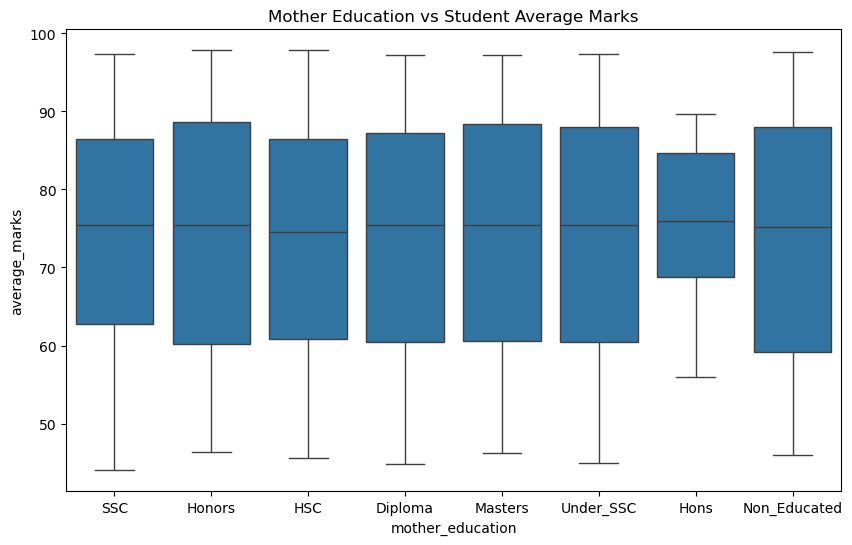

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='mother_education',
    y='average_marks',
    data=df
)

plt.title("Mother Education vs Student Average Marks")

plt.show()

“No strong relationship exists”

In [20]:
df.groupby('mother_education')['average_marks'].mean().sort_values()

mother_education
HSC             73.508467
Non_Educated    73.755140
Diploma         73.934927
Under_SSC       74.126899
SSC             74.303595
Masters         74.523226
Honors          74.848633
Hons            75.929268
Name: average_marks, dtype: float64

Mother education alone does not significantly influence
student performance in this dataset.

# Predicting Student Academic Performance Using Family and Educational Background

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           8612 non-null   int64  
 1   full_name                    8612 non-null   object 
 2   age                          8612 non-null   int64  
 3   gender                       8612 non-null   object 
 4   location                     8612 non-null   object 
 5   family_size                  8612 non-null   int64  
 6   mother_education             8612 non-null   object 
 7   father_education             8612 non-null   object 
 8   mother_job                   8612 non-null   object 
 9   father_job                   8612 non-null   object 
 10  guardian                     8612 non-null   object 
 11  parental_involvement         8612 non-null   object 
 12  internet_access              8612 non-null   object 
 13  studytime         

In [22]:
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group,average_marks
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Private,95,Yes,95,98,92,94,98,Science,95.4
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,Semi_Govt,92,No,65,71,40,78,80,Commerce,66.8
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Govt,81,Yes,64,78,58,86,74,Commerce,72.0
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Private,90,Yes,84,90,85,86,88,Science,86.6
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Semi_Govt,75,Yes,54,70,45,79,76,Commerce,64.8


# Encode data
